In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/company_financial_data.csv")

print("Shape:", df.shape)

print("\nColumn types:\n", df.dtypes)

print("\nMissing values:\n", df.isnull().sum())

print("\nBasic stats:\n")
print(df.describe().round(3))

Shape: (350, 18)

Column types:
 company                      object
sector                       object
year                          int64
current_ratio               float64
debt_to_equity              float64
roa                         float64
roe                         float64
gross_margin                float64
operating_margin            float64
interest_coverage           float64
asset_turnover              float64
revenue_growth              float64
cash_ratio                  float64
altman_z_score              float64
mda_sentiment               float64
news_sentiment              float64
days_payable_outstanding    float64
distressed                    int64
dtype: object

Missing values:
 company                     0
sector                      0
year                        0
current_ratio               0
debt_to_equity              0
roa                         0
roe                         0
gross_margin                0
operating_margin            0
interest_coverage

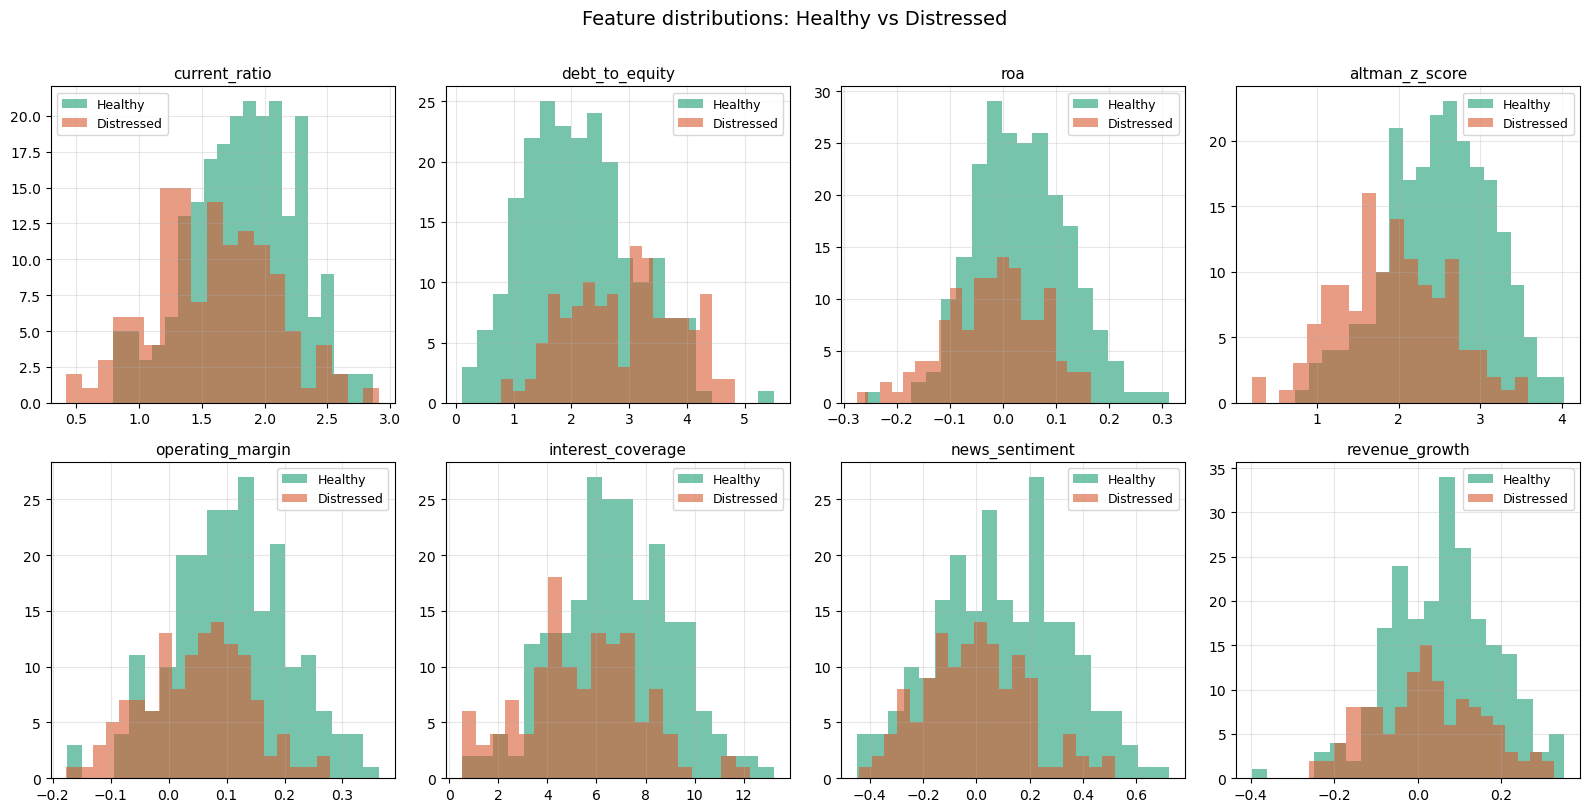

Chart saved to reports/01_distributions.png


In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

features = ["current_ratio","debt_to_equity","roa","altman_z_score",
            "operating_margin","interest_coverage","news_sentiment","revenue_growth"]

for i, feat in enumerate(features):
    for label, color in [(0,"#1D9E75"),(1,"#D85A30")]:
        subset = df[df["distressed"]==label][feat]
        axes[i].hist(subset, bins=20, alpha=0.6, color=color,
                     label="Healthy" if label==0 else "Distressed")
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle("Feature distributions: Healthy vs Distressed", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("reports/01_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to reports/01_distributions.png")


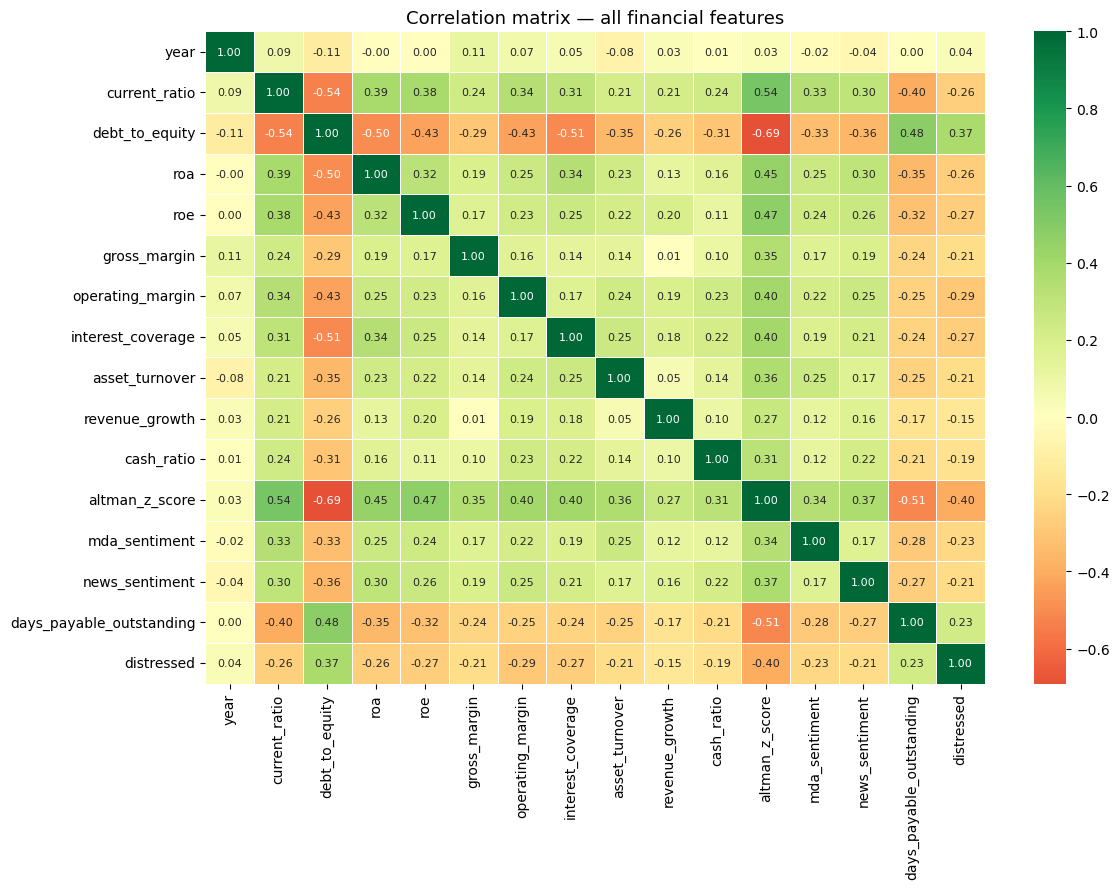

In [3]:
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.4, annot_kws={"size":8})
plt.title("Correlation matrix — all financial features", fontsize=13)
plt.tight_layout()
plt.savefig("reports/02_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


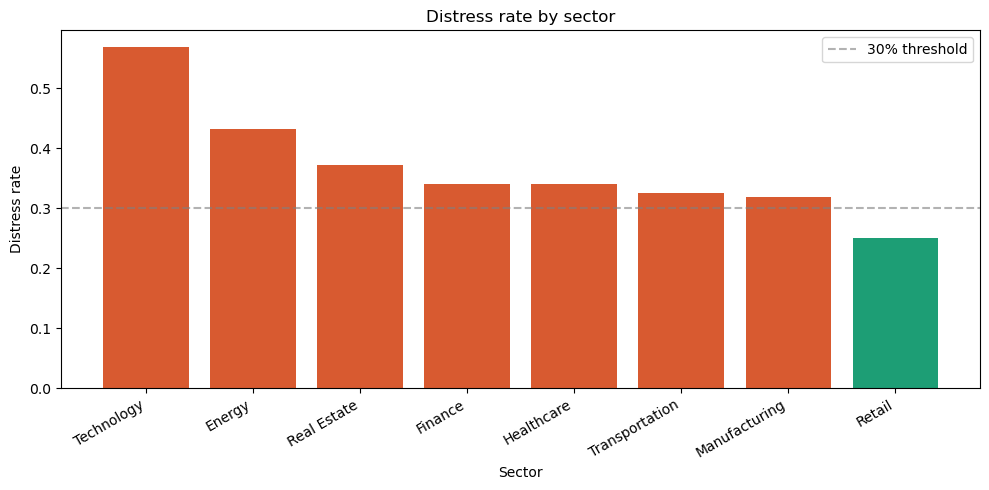

In [4]:
sector_risk = df.groupby("sector")["distressed"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(sector_risk.index, sector_risk.values,
               color=["#D85A30" if v > 0.3 else "#1D9E75" for v in sector_risk.values])
plt.axhline(0.3, linestyle="--", color="gray", alpha=0.6, label="30% threshold")
plt.xlabel("Sector")
plt.ylabel("Distress rate")
plt.title("Distress rate by sector")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("reports/03_sector_risk.png", dpi=150, bbox_inches="tight")
plt.show()
